In [1]:
# =========================
# 1) IMPORT & PATHS
# =========================
import os, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except Exception as e:
    HAS_LGBM = False
    print("LightGBM not available. Install with: pip install lightgbm")

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception as e:
    HAS_XGB = False
    print("XGBoost not available. Install with: pip install xgboost")

# =========================
# PATH DATASET (punya kamu)
# =========================
BASE_DIR = os.path.expanduser(r"~/Documents/dibimbing/AI_ML/Final Session")
DATASET_MAIN_DIR = os.path.join(BASE_DIR, "Dataset", "Global E-Commerce Dataset 2024–2026")
DATASET_TRENDS_DIR = os.path.join(BASE_DIR, "Dataset", "Global E-commerce Trends 2026")

print("BASE_DIR:", BASE_DIR)
print("MAIN_DIR:", DATASET_MAIN_DIR)
print("TRENDS_DIR:", DATASET_TRENDS_DIR)

XGBoost not available. Install with: pip install xgboost
BASE_DIR: C:\Users\PREDATOR/Documents/dibimbing/AI_ML/Final Session
MAIN_DIR: C:\Users\PREDATOR/Documents/dibimbing/AI_ML/Final Session\Dataset\Global E-Commerce Dataset 2024–2026
TRENDS_DIR: C:\Users\PREDATOR/Documents/dibimbing/AI_ML/Final Session\Dataset\Global E-commerce Trends 2026


In [2]:
# =========================
# 2) LOAD DATA
# =========================
main_files = glob.glob(os.path.join(DATASET_MAIN_DIR, "*.csv"))
trend_files = glob.glob(os.path.join(DATASET_TRENDS_DIR, "*.csv"))

print("Main files:", main_files, "| total:", len(main_files))
print("Trend files:", trend_files, "| total:", len(trend_files))

# pilih file (ubah kalau kamu mau pilih manual)
PATH_MAIN = main_files[0]
PATH_TRENDS = trend_files[0]

df = pd.read_csv(PATH_MAIN)
df_trends = pd.read_csv(PATH_TRENDS)

print("df shape:", df.shape)
print("df_trends shape:", df_trends.shape)

display(df.head())
display(df_trends.head())

Main files: ['C:\\Users\\PREDATOR/Documents/dibimbing/AI_ML/Final Session\\Dataset\\Global E-Commerce Dataset 2024–2026\\ecommerce_dataset_+1m.csv'] | total: 1
Trend files: ['C:\\Users\\PREDATOR/Documents/dibimbing/AI_ML/Final Session\\Dataset\\Global E-commerce Trends 2026\\ecommerce_trends_2026.csv'] | total: 1
df shape: (1000123, 62)
df_trends shape: (6000, 16)


,order_id,order_date,order_year,order_month,order_day,order_hour,order_minute,order_second,is_weekend,order_status,...,campaign_source,device_type,traffic_source,session_duration_minutes,pages_visited,abandoned_cart_before,fraud_risk_score,profit_margin_percent,order_priority,support_ticket_created
0,ORD-XAJI0,2024-10-14 11:20:05.496679,2024,10,14,11,20,5,No,Completed,...,Email,Mobile,Search,52.1,13,No,45.3,28.66,Medium,Yes
1,ORD-NHJ7X,2024-10-21 00:49:44.681065,2024,10,21,0,49,44,No,Completed,...,Google Ads,Desktop,Referral,36.2,15,No,97.1,33.91,Low,Yes
2,ORD-YTJXE,2025-03-17 19:49:36.983317,2025,3,17,19,49,36,No,Completed,...,Facebook,Tablet,Search,43.1,13,No,43.8,52.77,High,No
3,ORD-EIMVI,2024-09-27 06:24:44.913768,2024,9,27,6,24,44,No,Completed,...,Instagram,Mobile,Direct,39.5,18,Yes,96.9,38.15,Low,Yes
4,ORD-OR56F,2025-05-21 17:10:48.401882,2025,5,21,17,10,48,No,Completed,...,Facebook,Tablet,Social,28.0,3,Yes,45.8,33.05,High,Yes


,Transaction_ID,Customer_ID,Purchase_Date,Customer_Name,Customer_Age,Customer_Gender,Customer_Location,Annual_Income,Product_Category,Product_Price,Quantity,Total_Purchase_Amount,Payment_Method,Shipping_Duration,Customer_Rating,Churn_Risk
0,23b8c1e9-3924-46de-beb1-3b9046685257,bdd640fb-0667-4ad1-9c80-317fa3b1799d,2025-03-04,Megan Mcclain,22,Male,San Diego,47256,Electronics,1323.28,2,2646.56,Debit Card,2,4.5,Low
1,3b8faa18-37f8-488b-97fc-695a07a0ca6e,0822e8f3-6c03-4199-972a-846916419f82,2026-11-07,Alyssa Gonzalez,54,Male,Los Angeles,84990,Toys & Hobbies,197.14,1,197.14,PayPal,1,4.2,Low
2,47378190-96da-4dac-b2ff-5d2a386ecbe0,6b65a6a4-8b81-48f6-b38a-088ca65ed389,2025-02-19,Abigail Shaffer,32,Female,San Antonio,40786,Toys & Hobbies,142.45,1,142.45,PayPal,1,4.8,Low
3,c37459ee-f50b-4a63-b71e-cd7b27cd8130,47229389-571a-4876-ac30-7511b2b9437a,2026-06-27,Brandon Davis,68,Female,San Jose,98903,Fashion,207.60,1,207.60,Credit Card,2,4.5,Low
4,759cde66-bacf-43d0-8b1f-9163ce9ff57f,43b7a3a6-9a8d-4a03-980d-7b71d8f56413,2025-04-28,Valerie Gray,35,Female,Chicago,66648,Books,16.50,2,33.00,Buy Now Pay Later,3,4.4,Low


In [3]:
# =========================
# 3) DEFINE DATE & TARGET + CLEANING
# =========================
DATE_COL = "order_date"
TARGET_COL = "total_price_usd"

# convert types
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")

# drop nulls
df = df.dropna(subset=[DATE_COL, TARGET_COL]).copy()

# sort time
df = df.sort_values(DATE_COL)

print("min/max date:", df[DATE_COL].min(), df[DATE_COL].max())
print("target stats:")
print(df[TARGET_COL].describe())

min/max date: 2024-02-03 04:31:57.621140 2026-02-02 16:03:01.727725
target stats:
count    1.000123e+06
mean     4.032363e+02
std      3.701324e+02
min      7.530000e+00
25%      1.390200e+02
50%      2.901900e+02
75%      5.457600e+02
max      2.499750e+03
Name: total_price_usd, dtype: float64


In [4]:
# =========================
# 4) BUILD MONTHLY TARGET (y)
# =========================
y = (
    df.set_index(DATE_COL)[TARGET_COL]
      .resample("MS")     # month start
      .sum()
      .asfreq("MS")
      .fillna(0)
      .sort_index()
)

# clip outlier ringan (opsional, biar stabil)
q1, q99 = y.quantile([0.01, 0.99])
y = y.clip(q1, q99)

# --- FIX: buang bulan terakhir kalau tidak full (penting untuk kasus Feb 2026 kamu) ---
# --- OPTION: replace incomplete last month with mean ---
last_dt = df[DATE_COL].max()
month_start = last_dt.to_period("M").to_timestamp()
next_month_start = (last_dt.to_period("M") + 1).to_timestamp()
month_end = next_month_start - pd.Timedelta(seconds=1)

if last_dt < month_end:
    # rata-rata 6 bulan terakhir (atau seluruh bulan selain last)
    mean_value = y.iloc[:-1].tail(6).mean() if len(y) > 6 else y.iloc[:-1].mean()
    y.iloc[-1] = mean_value
    print("Replaced incomplete last month with mean:", month_start.date(), "->", mean_value)
print("y monthly points:", len(y), "|", y.index.min().date(), "to", y.index.max().date())
display(y.head())

Replaced incomplete last month with mean: 2026-02-01 -> 16958566.111466665
y monthly points: 25 | 2024-02-01 to 2026-02-01


order_date
2024-02-01    14902321.46
2024-03-01    17139579.61
2024-04-01    16743680.47
2024-05-01    17203051.20
2024-06-01    16440525.74
Freq: MS, Name: total_price_usd, dtype: float64

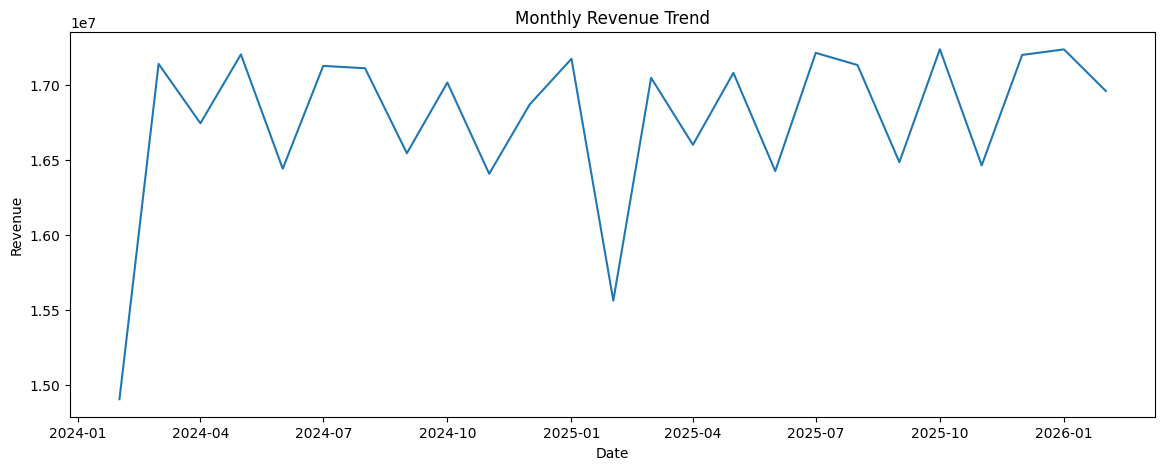

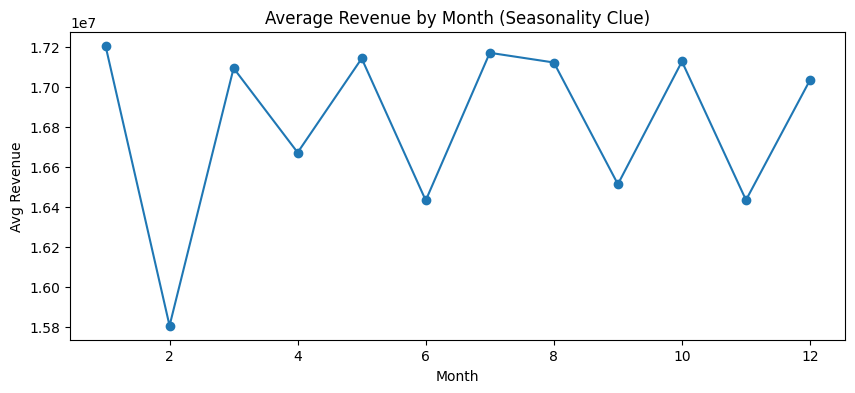

In [5]:
# =========================
# 5) EDA
# =========================
plt.figure(figsize=(14,5))
plt.plot(y.index, y.values)
plt.title("Monthly Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

month_profile = y.groupby(y.index.month).mean()
plt.figure(figsize=(10,4))
plt.plot(month_profile.index, month_profile.values, marker="o")
plt.title("Average Revenue by Month (Seasonality Clue)")
plt.xlabel("Month")
plt.ylabel("Avg Revenue")
plt.show()

In [6]:
# =========================
# 6) INTERNAL EXOG (MONTHlY)
# =========================
candidate_cols = [
    "discount_percent", "quantity", "delivery_days",
    "fraud_risk_score", "session_duration_minutes", "pages_visited"
]
avail = [c for c in candidate_cols if c in df.columns]
print("Internal cols used:", avail)

agg = {c: "mean" for c in avail}
agg[TARGET_COL] = "sum"

monthly_df = (
    df.set_index(DATE_COL)
      .resample("MS")
      .agg(agg)
      .asfreq("MS")
      .fillna(0)
)

# align ke index y (penting setelah drop incomplete month)
monthly_df = monthly_df.reindex(y.index).fillna(0)

# exog internal
internal_exog = monthly_df.drop(columns=[TARGET_COL], errors="ignore").copy()

# orders count (lebih informatif)
orders_cnt = (
    df.set_index(DATE_COL)["order_id"]
      .resample("MS")
      .nunique()
      .reindex(y.index)
      .fillna(0)
)
internal_exog["orders_cnt"] = orders_cnt

print("internal_exog shape:", internal_exog.shape)
display(internal_exog.head())

Internal cols used: ['discount_percent', 'quantity', 'delivery_days', 'fraud_risk_score', 'session_duration_minutes', 'pages_visited']
internal_exog shape: (25, 7)


,discount_percent,quantity,delivery_days,fraud_risk_score,session_duration_minutes,pages_visited,orders_cnt
order_date,,,,,,,
2024-02-01,8.521942,2.996302,7.526503,50.138546,30.531850,10.524965,37048
2024-03-01,8.474810,3.006016,7.513765,50.051201,30.612122,10.527999,42701
2024-04-01,8.501026,3.011373,7.505517,49.834821,30.550059,10.552215,41395
2024-05-01,8.480690,2.995035,7.490105,49.861880,30.689119,10.491182,42680
2024-06-01,8.558126,3.003877,7.503141,50.123540,30.433070,10.533394,40745


In [7]:
# =========================
# 7) SKIP TRENDS EXOG
# =========================
# Berdasarkan evaluasi:
# - trend dataset hanya overlap sebagian periode
# - banyak bulan awal bernilai 0
# - berisiko menyebabkan bias & overfitting
# Maka trend_exog tidak digunakan dalam modelling utama

trend_exog = pd.DataFrame(index=y.index)  # kosong saja
print("Trend exog disabled for stability.")

Trend exog disabled for stability.


In [24]:
# =========================
# 8) FEATURE ENGINEERING
# =========================
exog = internal_exog.copy().fillna(0)

# calendar
exog["month"] = exog.index.month
exog["quarter"] = exog.index.quarter
exog["year"] = exog.index.year

# lag dari y (target)
for lag in [1,2,3,6,12]:
    exog[f"y_lag_{lag}"] = y.shift(lag)

# rolling stats
for w in [3,6,12]:
    exog[f"y_roll_mean_{w}"] = y.rolling(w).mean()
    exog[f"y_roll_std_{w}"]  = y.rolling(w).std()

# isi NA
exog = exog.fillna(0)

print("exog shape:", exog.shape)
display(exog.head())

exog shape: (25, 21)


,discount_percent,quantity,delivery_days,fraud_risk_score,session_duration_minutes,pages_visited,orders_cnt,month,quarter,year,...,y_lag_2,y_lag_3,y_lag_6,y_lag_12,y_roll_mean_3,y_roll_std_3,y_roll_mean_6,y_roll_std_6,y_roll_mean_12,y_roll_std_12
order_date,,,,,,,,,,,,,,,,,,,,,
2024-02-01,8.521942,2.996302,7.526503,50.138546,30.531850,10.524965,37048,2,1,2024,...,0.00,0.00,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0
2024-03-01,8.474810,3.006016,7.513765,50.051201,30.612122,10.527999,42701,3,1,2024,...,0.00,0.00,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0
2024-04-01,8.501026,3.011373,7.505517,49.834821,30.550059,10.552215,41395,4,2,2024,...,14902321.46,0.00,0.0,0.0,1.626186e+07,1.193920e+06,0.0,0.0,0.0,0.0
2024-05-01,8.480690,2.995035,7.490105,49.861880,30.689119,10.491182,42680,5,2,2024,...,17139579.61,14902321.46,0.0,0.0,1.702877e+07,2.489264e+05,0.0,0.0,0.0,0.0
2024-06-01,8.558126,3.003877,7.503141,50.123540,30.433070,10.533394,40745,6,2,2024,...,16743680.47,17139579.61,0.0,0.0,1.679575e+07,3.839204e+05,0.0,0.0,0.0,0.0


In [9]:
# =========================
# 9) FEATURE SELECTION
# =========================
X = exog.copy()

# Mutual Information (ranking cepat)
mi = mutual_info_regression(X.values, y.values, random_state=42)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

print("Top 15 MI features:")
display(mi_series.head(15))

# Permutation importance (pakai Ridge baseline)
split_point = int(len(X) * 0.85)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

baseline = Ridge(alpha=1.0, random_state=42)
baseline.fit(X_train, y_train)

perm = permutation_importance(baseline, X_test, y_test, n_repeats=20, random_state=42)
perm_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

print("Top 15 Permutation features:")
display(perm_imp.head(15))

# pilih fitur final (gabungan)
top_mi = set(mi_series.head(20).index)
top_perm = set(perm_imp.head(20).index)
selected_features = sorted(list(top_mi.intersection(top_perm)))

# fallback kalau terlalu sedikit
if len(selected_features) < 8:
    selected_features = sorted(list(top_mi.union(top_perm)))[:20]

print("Selected features:", selected_features)
X_sel = X[selected_features].copy()

Top 15 MI features:


orders_cnt                  0.597911
y_lag_2                     0.157109
y_lag_1                     0.152639
y_roll_mean_3               0.142908
quantity                    0.136182
y_roll_std_3                0.133289
delivery_days               0.050237
quarter                     0.044742
y_lag_12                    0.025402
y_lag_3                     0.008295
session_duration_minutes    0.000000
discount_percent            0.000000
fraud_risk_score            0.000000
year                        0.000000
month                       0.000000
dtype: float64

Top 15 Permutation features:


month                       13.891702
y_roll_std_3                 1.209807
y_roll_mean_3                0.249445
y_roll_std_6                 0.188397
y_lag_1                      0.137302
session_duration_minutes     0.099360
y_lag_3                      0.082507
y_roll_mean_6                0.034763
delivery_days                0.014618
pages_visited                0.004354
discount_percent             0.002154
quantity                    -0.000370
year                        -0.001912
y_lag_6                     -0.062723
fraud_risk_score            -0.078039
dtype: float64

Selected features: ['delivery_days', 'discount_percent', 'fraud_risk_score', 'month', 'orders_cnt', 'pages_visited', 'quantity', 'quarter', 'session_duration_minutes', 'y_lag_1', 'y_lag_12', 'y_lag_2', 'y_lag_3', 'y_lag_6', 'y_roll_mean_12', 'y_roll_mean_3', 'y_roll_mean_6', 'y_roll_std_3', 'y_roll_std_6', 'year']


In [10]:
# =========================
# 10) ML MODEL COMPARISON (TimeSeriesSplit CV) + LGBM + XGB
# =========================
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denom = np.maximum(np.abs(y_true), 1e-9)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

tscv = TimeSeriesSplit(n_splits=5)

models = {
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "RandomForest": RandomForestRegressor(
        n_estimators=600, random_state=42, n_jobs=-1,
        max_depth=6, min_samples_leaf=2
    ),
    "GradientBoosting": GradientBoostingRegressor(
        random_state=42, n_estimators=600, learning_rate=0.05, max_depth=3
    ),
}

# Tambahkan LightGBM jika tersedia
if HAS_LGBM:
    models["LightGBM"] = LGBMRegressor(
        random_state=42,
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=10
    )

# Tambahkan XGBoost jika tersedia
if HAS_XGB:
    models["XGBoost"] = XGBRegressor(
        random_state=42,
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:squarederror"
    )

rows = []
for name, model in models.items():
    for fold, (tr, te) in enumerate(tscv.split(X_sel), start=1):
        X_tr, X_te = X_sel.iloc[tr], X_sel.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]

        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)

        rows.append({
            "Model": name,
            "Fold": fold,
            "MAE": mean_absolute_error(y_te, pred),
            "RMSE": rmse(y_te, pred),
            "MAPE%": mape(y_te, pred),
        })

cv_df = pd.DataFrame(rows)

cv_summary = (
    cv_df.groupby("Model")[["MAE","RMSE","MAPE%"]]
         .mean()
         .sort_values("RMSE")
)

print("=== CV Summary (lower is better) ===")
display(cv_summary)

best_ml_cv = cv_summary.index[0]
print("✅ Best ML (CV):", best_ml_cv)

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 5, number of used features: 0
[LightGBM] [Info] Start training from score 16485831.800000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet th

,MAE,RMSE,MAPE%
Model,,,
RandomForest,2.708114e+05,3.449445e+05,1.610433
GradientBoosting,2.402153e+05,3.515912e+05,1.413022
LightGBM,3.669142e+05,4.271060e+05,2.186161
Ridge,1.750903e+06,2.626319e+06,10.537722


✅ Best ML (CV): RandomForest


In [18]:
# =========================
# 11) FINAL EVALUATION (SARIMAX + ALL ML) - HOLDOUT + SUMMARY
# =========================
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denom = np.maximum(np.abs(y_true), 1e-9)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

# -------------------------
# 1) Time-based holdout split
# -------------------------
split_point = int(len(y) * 0.8)   # 80/20
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]
X_train, X_test = X_sel.iloc[:split_point], X_sel.iloc[split_point:]

print("Train months:", len(y_train), "| Test months:", len(y_test))
print("Test period:", y_test.index.min().date(), "to", y_test.index.max().date())

# -------------------------
# 2) SARIMAX Holdout
# -------------------------
sarimax_holdout = SARIMAX(
    y_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

pred_sarimax = sarimax_holdout.get_forecast(steps=len(y_test)).predicted_mean

sarimax_mae  = mean_absolute_error(y_test, pred_sarimax)
sarimax_rmse = rmse(y_test, pred_sarimax)
sarimax_mape = mape(y_test, pred_sarimax)

print("\n=== SARIMAX Holdout ===")
print("MAE :", sarimax_mae)
print("RMSE:", sarimax_rmse)
print("MAPE%:", sarimax_mape)

# -------------------------
# 3) Build ALL ML models (same as CV set)
# -------------------------
all_models = {
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "RandomForest": RandomForestRegressor(
        n_estimators=600, random_state=42, n_jobs=-1,
        max_depth=6, min_samples_leaf=2
    ),
    "GradientBoosting": GradientBoostingRegressor(
        random_state=42, n_estimators=600, learning_rate=0.05, max_depth=3
    ),
}

if "HAS_LGBM" in globals() and HAS_LGBM:
    all_models["LightGBM"] = LGBMRegressor(
        random_state=42,
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=10
    )

if "HAS_XGB" in globals() and HAS_XGB:
    all_models["XGBoost"] = XGBRegressor(
        random_state=42,
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:squarederror"
    )

# -------------------------
# 4) Holdout evaluate ALL ML
# -------------------------
ml_rows = []
for name, model in all_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    ml_rows.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": rmse(y_test, pred),
        "MAPE%": mape(y_test, pred),
    })

ml_holdout_df = pd.DataFrame(ml_rows).sort_values("RMSE")
print("\n=== ML Holdout (All Models) ===")
display(ml_holdout_df)

best_ml_holdout = ml_holdout_df.iloc[0]["Model"]
print("✅ Best ML (Holdout):", best_ml_holdout)

# -------------------------
# 5) Final summary (SARIMAX + Best ML)
#    (buat variabel baru biar gak campur dengan cell lama)
# -------------------------
best_ml_row = ml_holdout_df.iloc[0].to_dict()

summary_df_final = pd.DataFrame([
    {"Model":"SARIMAX (stable)", "MAE":sarimax_mae, "RMSE":sarimax_rmse, "MAPE%":sarimax_mape},
    {"Model":f"{best_ml_row['Model']} (ML)", "MAE":best_ml_row["MAE"], "RMSE":best_ml_row["RMSE"], "MAPE%":best_ml_row["MAPE%"]},
])

summary_df_final["Accuracy% (100-MAPE)"] = 100 - summary_df_final["MAPE%"]

print("\n=== FINAL SUMMARY (for report) ===")
display(summary_df_final.sort_values("RMSE"))

Train months: 20 | Test months: 5
Test period: 2025-10-01 to 2026-02-01

=== SARIMAX Holdout ===
MAE : 473273.3129006002
RMSE: 690584.3648588908
MAPE%: 2.7807178843650826
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000362 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8
[LightGBM] [Info] Number of data points in the train set: 20, number of used features: 1
[LightGBM] [Info] Start training from score 16710697.100000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

,Model,MAE,RMSE,MAPE%
3,LightGBM,3.742637e+05,4.221434e+05,2.184481
1,RandomForest,3.631475e+05,5.546166e+05,2.131491
2,GradientBoosting,3.983483e+05,7.499565e+05,2.343537
0,Ridge,3.146675e+06,6.851272e+06,18.550018


✅ Best ML (Holdout): LightGBM

=== FINAL SUMMARY (for report) ===


,Model,MAE,RMSE,MAPE%,Accuracy% (100-MAPE)
1,LightGBM (ML),374263.656651,422143.388272,2.184481,97.815519
0,SARIMAX (stable),473273.312901,690584.364859,2.780718,97.219282


In [19]:
# =========================
# LIGHTGBM 24-MONTH FORECAST (RECURSIVE)
# =========================
import numpy as np
import pandas as pd

# pastikan lightgbm tersedia
assert HAS_LGBM, "LightGBM belum tersedia. Install: pip install lightgbm"

from lightgbm import LGBMRegressor

H = 24  # horizon 24 bulan
future_index = pd.date_range(start=y.index.max(), periods=H+1, freq="MS")[1:]

# -------------------------
# 1) Train LightGBM on FULL data
# -------------------------
lgbm = LGBMRegressor(
    random_state=42,
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=10
)
lgbm.fit(X_sel, y)

# -------------------------
# 2) Prepare base values for non-lag features
#    (untuk fitur internal seperti discount_percent, orders_cnt, dll)
# -------------------------
base_means = X_sel.mean()

# container pred
pred_list = []

# y_ext untuk update lag/rolling sepanjang forecast
y_ext = y.copy()

# helper untuk isi lag / rolling
def safe_last(series, n, default):
    return series.iloc[-n] if len(series) >= n else default

for dt in future_index:
    row = base_means.copy()

    # -------------------------
    # Calendar features (kalau ada di X_sel)
    # -------------------------
    if "month" in row.index:
        row["month"] = dt.month
    if "quarter" in row.index:
        row["quarter"] = ((dt.month - 1) // 3) + 1
    if "year" in row.index:
        row["year"] = dt.year

    # -------------------------
    # Lag features (kalau ada di X_sel)
    # -------------------------
    for lag in [1, 2, 3, 6, 12]:
        col = f"y_lag_{lag}"
        if col in row.index:
            row[col] = safe_last(y_ext, lag, y_ext.mean())

    # -------------------------
    # Rolling features (kalau ada di X_sel)
    # -------------------------
    for w in [3, 6, 12]:
        mcol = f"y_roll_mean_{w}"
        scol = f"y_roll_std_{w}"
        if mcol in row.index:
            row[mcol] = y_ext.iloc[-w:].mean() if len(y_ext) >= w else y_ext.mean()
        if scol in row.index:
            row[scol] = y_ext.iloc[-w:].std() if len(y_ext) >= w else y_ext.std()

    # pastikan urutan kolom sama persis
    X_future_1 = pd.DataFrame([row], index=[dt])[X_sel.columns]

    # prediksi 1-step
    y_hat = float(lgbm.predict(X_future_1)[0])
    pred_list.append(y_hat)

    # update y_ext untuk step berikutnya (recursive)
    y_ext = pd.concat([y_ext, pd.Series([y_hat], index=[dt])])

# hasil forecast
fcst_lgbm = pd.DataFrame({
    "Date": future_index,
    "Forecast_LightGBM": pred_list
})

display(fcst_lgbm.head())

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000476 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 167
[LightGBM] [Info] Number of data points in the train set: 25, number of used features: 20
[LightGBM] [Info] Start training from score 16772335.760000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

,Date,Forecast_LightGBM
0,2026-03-01,1.667741e+07
1,2026-04-01,1.667136e+07
2,2026-05-01,1.644140e+07
3,2026-06-01,1.644140e+07
4,2026-07-01,1.620731e+07


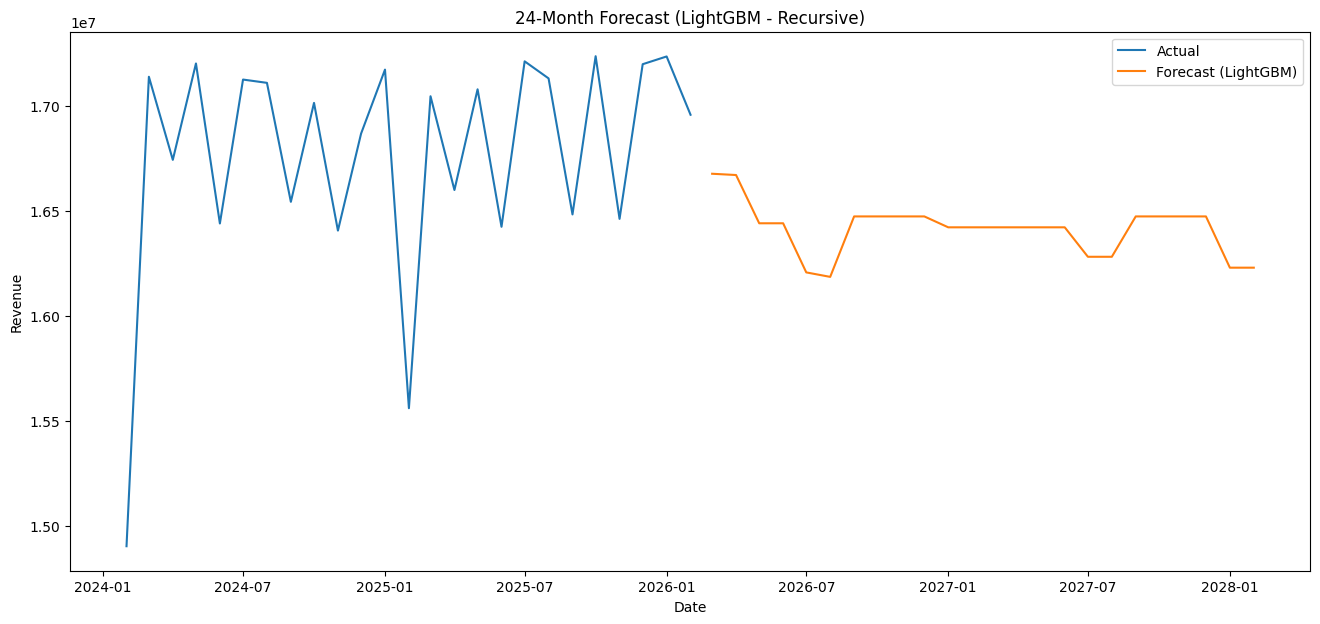

In [20]:
# plot compare actual vs LGBM forecast
import matplotlib.pyplot as plt
plt.figure(figsize=(16,7))
plt.plot(y.index, y.values, label="Actual")
plt.plot(fcst_lgbm["Date"], fcst_lgbm["Forecast_LightGBM"], label="Forecast (LightGBM)")
plt.title("24-Month Forecast (LightGBM - Recursive)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.show()

,Date,Forecast,Lower CI,Upper CI
0,2026-03-01,1.695586e+07,1.682807e+07,1.708364e+07
1,2026-04-01,1.634732e+07,1.611373e+07,1.658092e+07
2,2026-05-01,1.680952e+07,1.650158e+07,1.711746e+07
3,2026-06-01,1.711456e+07,1.674681e+07,1.748231e+07
4,2026-07-01,1.550083e+07,1.508171e+07,1.591996e+07


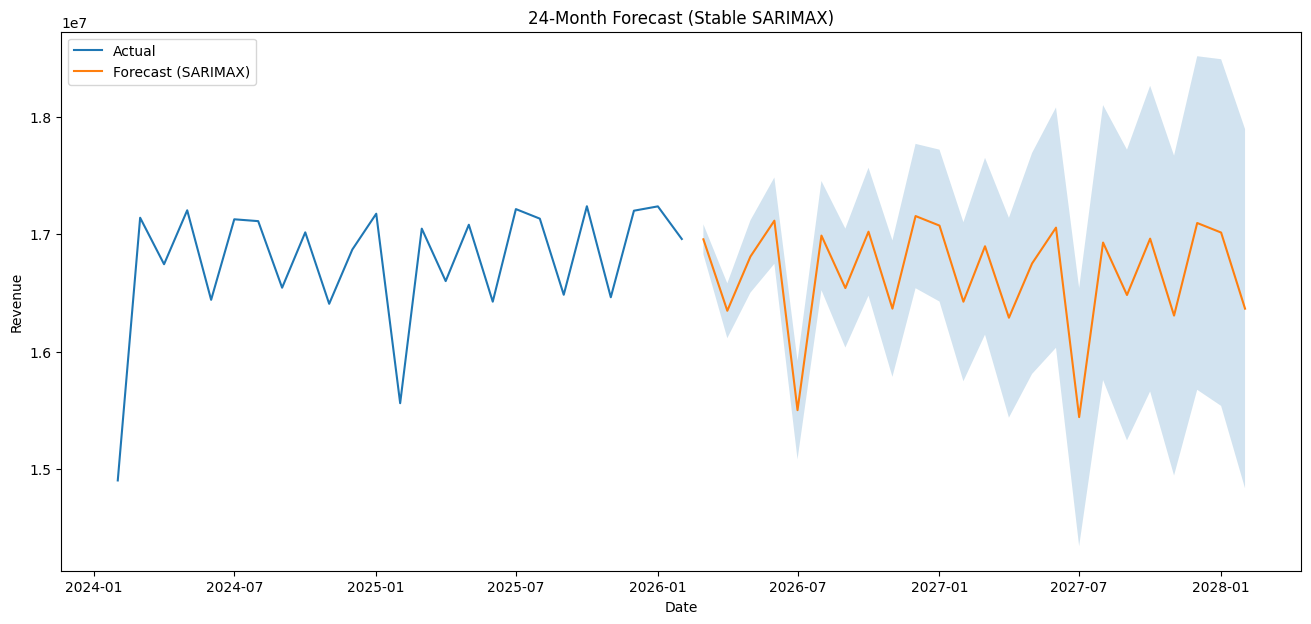

In [21]:
# =========================
# 12) FORECAST 24 MONTHS (STABLE) - REPLACE CELL 12
# =========================
H = 24  # 24 bulan ke depan

forecast_obj = sarimax_holdout.get_forecast(steps=H)

# mean forecast
forecast_mean = forecast_obj.predicted_mean

# confidence interval (CI)
ci = forecast_obj.conf_int(alpha=0.05)

# future index
future_index = pd.date_range(start=y.index.max(), periods=H+1, freq="MS")[1:]

# build dataframe output
fcst = pd.DataFrame({
    "Date": future_index,
    "Forecast": forecast_mean.values,
    "Lower CI": ci.iloc[:, 0].values,
    "Upper CI": ci.iloc[:, 1].values
})

display(fcst.head())

# plot
plt.figure(figsize=(16,7))
plt.plot(y.index, y.values, label="Actual")
plt.plot(fcst["Date"], fcst["Forecast"], label="Forecast (SARIMAX)")
plt.fill_between(fcst["Date"], fcst["Lower CI"], fcst["Upper CI"], alpha=0.2)
plt.title("24-Month Forecast (Stable SARIMAX)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.show()

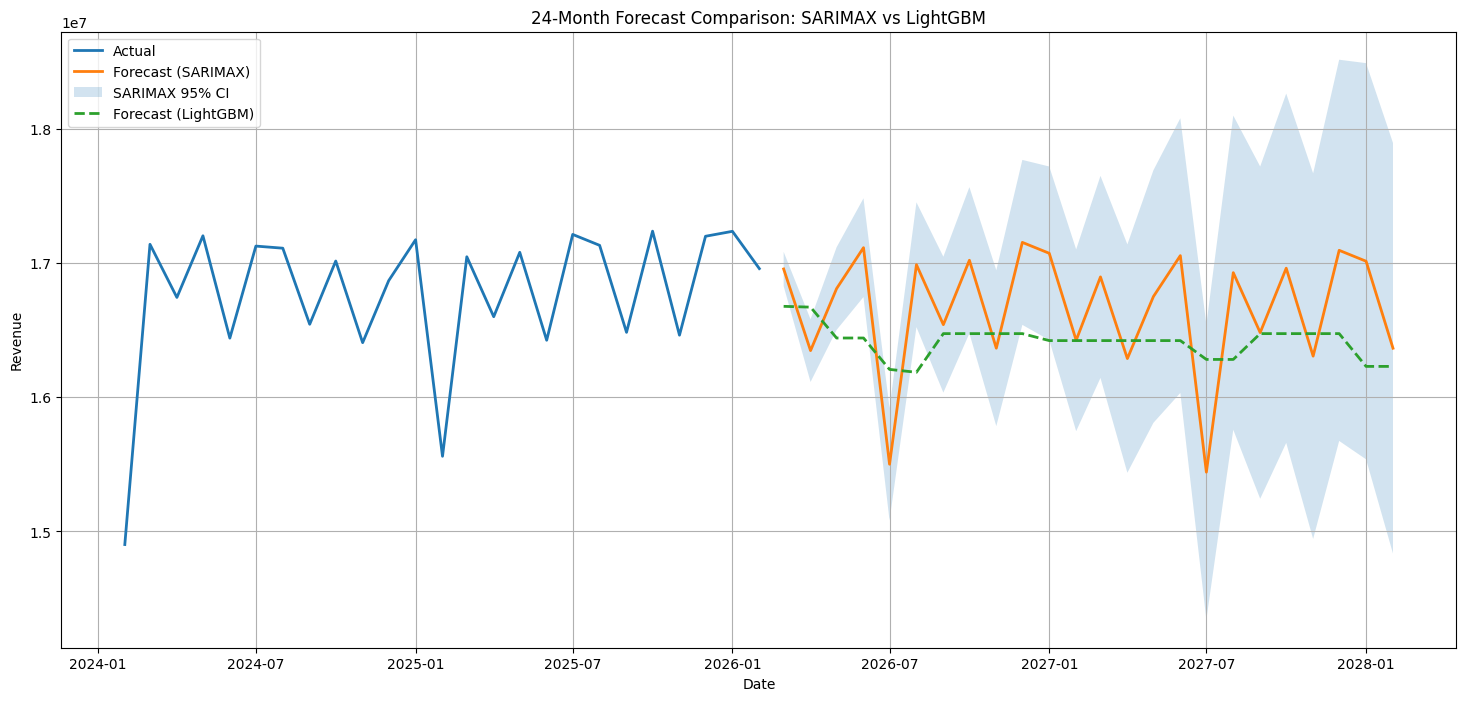

In [22]:
# =========================
# COMPARISON: SARIMAX vs LightGBM
# =========================
import matplotlib.pyplot as plt

plt.figure(figsize=(18,8))

# Actual
plt.plot(y.index, y.values, label="Actual", linewidth=2)

# SARIMAX
plt.plot(fcst["Date"], fcst["Forecast"], 
         label="Forecast (SARIMAX)", linewidth=2)

# Confidence Interval SARIMAX
plt.fill_between(
    fcst["Date"],
    fcst["Lower CI"],
    fcst["Upper CI"],
    alpha=0.2,
    label="SARIMAX 95% CI"
)

# LightGBM
plt.plot(fcst_lgbm["Date"], 
         fcst_lgbm["Forecast_LightGBM"], 
         label="Forecast (LightGBM)", 
         linestyle="--",
         linewidth=2)

plt.title("24-Month Forecast Comparison: SARIMAX vs LightGBM")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)
plt.show()